In [24]:
!pip install --upgrade bitsandbytes

In [25]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

print("Hello")

Tue Jan 20 10:51:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   29C    P0             51W /  400W |   26906MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [33]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

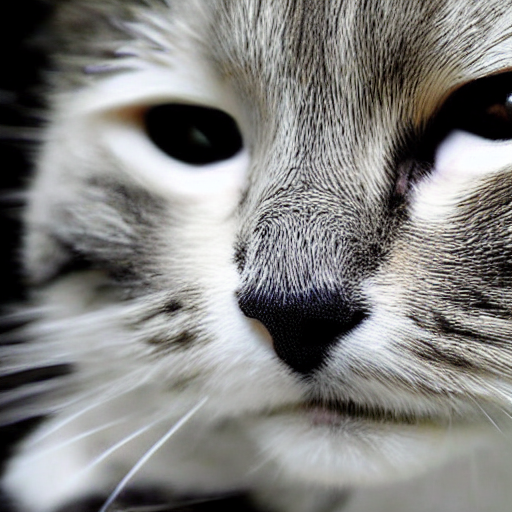

In [34]:
prompt = "a photo of a cat"
image = pipe(prompt).images[0]  
    
image.save("Test_SB_Image.png")

image

In [35]:
from diffusers import AutoencoderKL
import torch

# vae = AutoencoderKL.from_pretrained(
#     "runwayml/stable-diffusion-v1-5",
#     subfolder="vae",
#     torch_dtype=torch.float32
# ).to("cuda")

vae = pipe.vae

In [36]:
import numpy as np

img = np.array(image).astype(np.float32) / 255.0
img = torch.from_numpy(img).permute(2,0,1).unsqueeze(0).to("cuda", dtype=torch.float16)
img = img * 2.0 - 1.0  # [-1,1]

# Print Original Image Shape
print(f'Original Image Shape is: {img.shape}')

Original Image Shape is: torch.Size([1, 3, 512, 512])


In [37]:
with torch.no_grad():
    latent = vae.encode(img).latent_dist.sample() * 0.18215

print(f"Latent shape: {latent.shape}, dtype: {latent.dtype}")

Latent shape: torch.Size([1, 4, 64, 64]), dtype: torch.float16


In [38]:
with torch.no_grad():
    decoded = vae.decode(latent / 0.18215).sample

In [44]:
# decoded: [1,3,512,512] float16
decoded_float = (decoded + 1.0) / 2.0           # [-1,1] -> [0,1]
decoded_float = decoded_float.clamp(0,1).cpu()  # move to CPU

print(f'Shape of Decoded Image: {decoded_float.shape}')

# Convert to float32
decoded_float = decoded_float.float()           # float16 -> float32

# Permute and remove batch
decoded_numpy = decoded_float[0].permute(1,2,0).numpy()  # shape: [512,512,3]

# Convert to uint8 for PIL
decoded_uint8 = (decoded_numpy * 255).round().astype(np.uint8)

print(f'Shape of Decoded Image as uint8: {decoded_uint8.shape}, dtype: {decoded_uint8.dtype}')

from PIL import Image
Image.fromarray(decoded_uint8).save("reconstructed_image.png")

Shape of Decoded Image: torch.Size([1, 3, 512, 512])
Shape of Decoded Image as uint8: (512, 512, 3), dtype: uint8


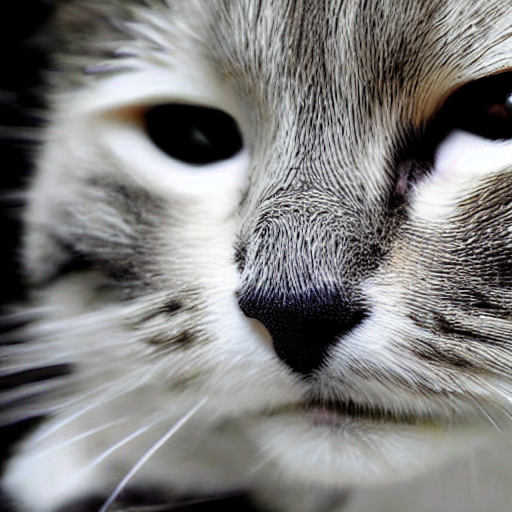

In [45]:
# Plot the Decoded Image
Image.fromarray(decoded_uint8)

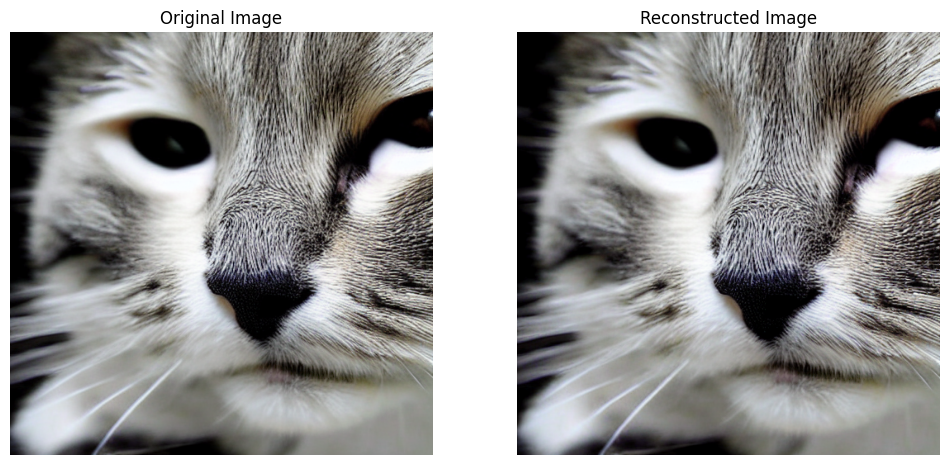

In [46]:
import matplotlib.pyplot as plt

# Get the original image from the dataset
original_image = Image.open("Test_SB_Image.png").convert("RGB")

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the original image
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off') # Hide axes ticks

# Display the decoded image
axes[1].imshow(decoded_uint8)
axes[1].set_title('Reconstructed Image')
axes[1].axis('off') # Hide axes ticks

plt.show()

Minimum difference: 0.0
Maximum difference: 1.8627451658248901


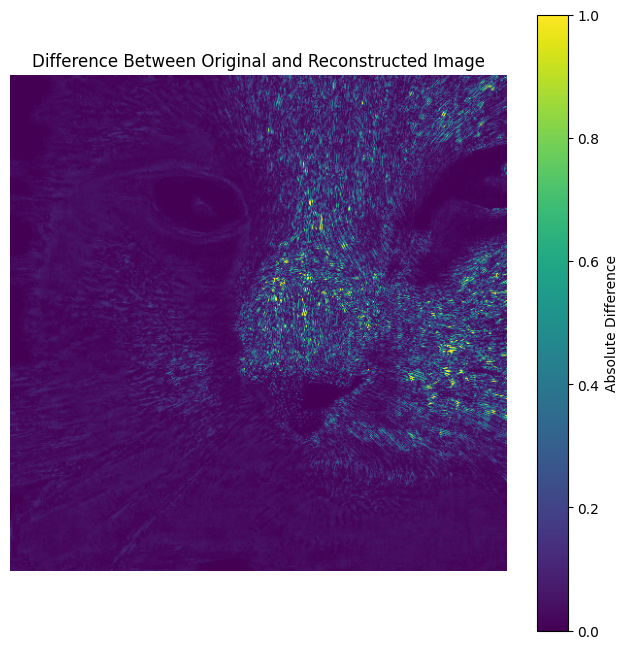

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms

# Ensure original_image is a PIL Image
original_image_pil = Image.open("Test_SB_Image.png").convert("RGB")

# Preprocess the original image to a tensor and convert to numpy for comparison
# We need to ensure it's in the same [0, 1] range and (H, W, C) format as image_numpy
preprocess_for_diff = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(), # Converts to [0, 1] range and (C, H, W)
])
original_image_tensor = preprocess_for_diff(original_image_pil)
original_image_numpy = original_image_tensor.permute(1, 2, 0).numpy()

# Calculate the absolute difference between the original and reconstructed images
# image_numpy is already in [0, 1] range and (H, W, C) format
# difference_image = np.abs(original_image_numpy - decoded).sum(axis=2)
decoded_float = decoded_uint8.astype(np.float32) / 255.0
difference_image = np.abs(original_image_numpy - decoded_float).sum(axis=2)

print(f"Minimum difference: {difference_image.min()}")
print(f"Maximum difference: {difference_image.max()}")

# Display the difference image with adjusted colormap and value range
plt.figure(figsize=(8, 8))
plt.imshow(difference_image,vmax=1.)
plt.title('Difference Between Original and Reconstructed Image')
plt.axis('off')
plt.colorbar(label='Absolute Difference')
plt.show()